# 07 · ARIMA, SARIMA and SARIMAX

Chapter 06 left us with a strong model and a hard ceiling. Beyond a couple of days, **nothing in PM2.5's own past** predicts its future much better than the seasonal profile. This chapter extends the ARMA family in three directions:

1. **ARIMA** puts the differencing from chapter 03 *inside* the model, for series with a unit root.
2. **SARIMA** adds seasonal differencing and seasonal AR/MA terms. CO₂ is the textbook case.
3. **SARIMAX** adds **external regressors**. For PM2.5 that means the weather, the one source of information that can break through the ceiling.

The last part raises a question that decides whether a forecast is honest: **what do you feed the model for future weather you haven't observed yet?** We'll answer it three ways and compare.

**By the end of this chapter you will be able to**

- explain what the *d* in ARIMA(p, d, q) does, and connect ARIMA(0,1,1) to exponential smoothing
- run the full residual check (Ljung–Box, Jarque–Bera, heteroskedasticity, Durbin–Watson) and an automatic order search with `auto_arima`
- read a **cross-correlation** to see whether an input leads the series
- read SARIMA notation, identify the classic **airline model** from ACF/PACF, and fit and check it
- build a **regression with ARMA errors** (SARIMAX) and interpret its coefficients
- tell an **oracle** evaluation from an honest one, and measure what perfect information would be worth
- use a practical refit schedule: refit monthly, update daily

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

import tsutils

tsutils.set_style()
pd.set_option("display.precision", 3)

daily = tsutils.load_daily_pm25()
y, actual = daily["pm25"], daily["actual"]
origins, H = tsutils.BACKTEST_ORIGINS, tsutils.HORIZON
co2 = sm.datasets.co2.load_pandas().data["co2"].resample("MS").mean().interpolate()

---
## 1. ARIMA: differencing inside the model

An **ARIMA(p, d, q)** model differences the series $d$ times, then fits an ARMA(p, q) to the result. Using the backshift operator $B$ (so $B y_t = y_{t-1}$, and $(1 - B) y_t = y_t - y_{t-1}$):

$$\underbrace{(1 - \phi_1 B - \dots - \phi_p B^p)}_{\text{AR}}\;\underbrace{(1 - B)^d}_{\text{differencing}}\; y_t = c + \underbrace{(1 + \theta_1 B + \dots + \theta_q B^q)}_{\text{MA}}\;\varepsilon_t$$

Putting the differencing inside the model has a practical benefit. Forecasts come back **on the original scale**, and the intervals correctly reflect the accumulated uncertainty of the integrated series. The choice of $d$ should follow chapter 03: difference a unit root, don't difference a mean-reverting series.

Several models from earlier chapters are special cases:

| ARIMA | Equivalent to |
|---|---|
| (0, 1, 0) | random walk → the **naive** forecast |
| (0, 1, 0) with a constant | random walk with drift → the **drift** forecast |
| (0, 1, 1) | **simple exponential smoothing**, with $\alpha = 1 + \theta_1$ |

The last one is the least obvious, so let's check it on log PM2.5:

In [2]:
log_train = np.log(y[:"2013-12-31"]).to_numpy()

arima011 = ARIMA(log_train, order=(0, 1, 1)).fit()
ses = SimpleExpSmoothing(log_train, initialization_method="estimated").fit()

theta = arima011.params[0]
print(f"ARIMA(0,1,1): θ = {theta:.3f}  ->  implied α = 1 + θ = {1 + theta:.3f}")
print(f"SES (chapter 05):              estimated α = {ses.params['smoothing_level']:.3f}")
print(f"next-day forecasts: {arima011.forecast(1)[0]:.4f} vs {ses.forecast(1)[0]:.4f}")

ARIMA(0,1,1): θ = -0.366  ->  implied α = 1 + θ = 0.634
SES (chapter 05):              estimated α = 0.633
next-day forecasts: 3.8767 vs 3.8765


Two different estimation methods, one answer. This equivalence also explains chapter 05's result from a new angle: SES is an **integrated** model. It assumes a unit root, so it can never revert to a mean, and PM2.5 doesn't have a unit root (chapter 03). ARIMA(2,0,0), with $d = 0$, was the right member of the family.

---
## 2. SARIMA: seasonal ARIMA

A seasonal series with period $m$ can depend on the same season last year as well as on last month. **SARIMA(p, d, q)(P, D, Q)ₘ** adds a second set of terms that work at multiples of $m$:

- $D$: seasonal differences, $(1 - B^m)$, i.e. $y_t - y_{t-m}$ (chapter 03)
- $P$: seasonal AR terms, on $y_{t-m}, y_{t-2m}, \dots$
- $Q$: seasonal MA terms, on $\varepsilon_{t-m}, \varepsilon_{t-2m}, \dots$

The seasonal and non-seasonal parts **multiply**. The most famous SARIMA, (0,1,1)(0,1,1)₁₂, was made popular by Box and Jenkins for airline passenger data and is still known as the **airline model**:

$$(1 - B)(1 - B^{12})\, y_t = (1 + \theta B)(1 + \Theta B^{12})\, \varepsilon_t.$$

Multiplying out the right-hand side gives MA terms at lags 1, 12 **and 13** ($\theta\Theta$), from only two parameters. That's the appeal of the multiplicative form: rich structure, few parameters.

### Identifying a SARIMA for CO₂

Chapter 03 established that CO₂ needs one regular and one seasonal difference ($d = D = 1$). What does the doubly-differenced series look like?

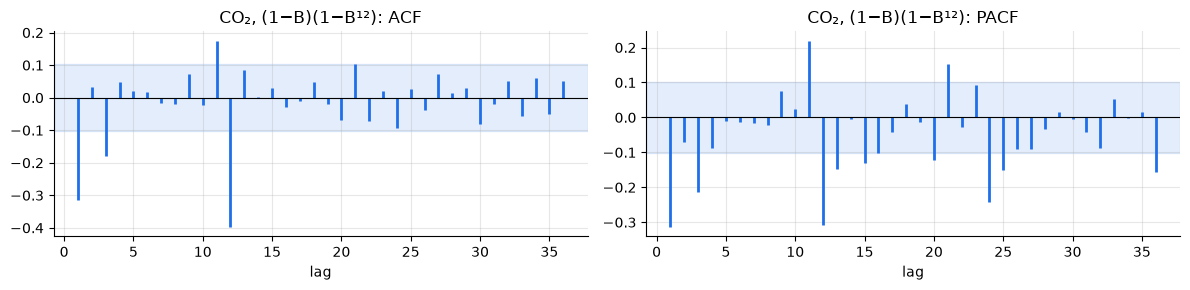

In [3]:
co2_train = co2[:"1989-12"]
double_diff = co2_train.diff().diff(12).dropna()
tsutils.plot_acf_pacf(double_diff, lags=36, title="CO₂, (1−B)(1−B¹²):")

The two dominant features of the ACF are **negative spikes at lag 1 and lag 12**, with smaller positive side-spikes at lags 11 and 13 (Exercise 1 shows the airline model *predicts* those) and a modest one at lag 3. The PACF decays from lag 1 and again from lag 12. Negative ACF spikes with a decaying PACF are the MA(1) fingerprint (chapter 06), once at the regular lag and once at the seasonal lag. That's the airline model: MA(1) × seasonal MA(1).

Let's confirm with a small search over the other orders ($p, q, P, Q \le 1$, with $d = D = 1$ fixed).

In [4]:
rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for p in range(2):
        for q in range(2):
            for P in range(2):
                for Q in range(2):
                    fit = SARIMAX(co2_train, order=(p, 1, q), seasonal_order=(P, 1, Q, 12)).fit(disp=False)
                    rows.append({"order": f"({p},1,{q})({P},1,{Q})₁₂", "AIC": fit.aic, "BIC": fit.bic})
pd.DataFrame(rows).set_index("order").sort_values("AIC").head(5)

,AIC,BIC
order,,
"(1,1,1)(0,1,1)₁₂",199.824,215.467
"(1,1,1)(1,1,1)₁₂",201.549,221.102
"(0,1,1)(0,1,1)₁₂",203.595,215.328
"(0,1,1)(1,1,1)₁₂",205.311,220.954
"(1,1,0)(0,1,1)₁₂",211.795,223.528


The criteria split. **BIC**, with its heavier penalty, prefers the two-parameter **airline model** by a whisker. **AIC** prefers adding a regular AR term, (1,1,1)(0,1,1)₁₂. Let's look at both fits' residuals:

In [5]:
candidates = {"airline (0,1,1)(0,1,1)": (0, 1, 1), "(1,1,1)(0,1,1)": (1, 1, 1)}
co2_fits = {name: SARIMAX(co2_train, order=order, seasonal_order=(0, 1, 1, 12)).fit(disp=False)
            for name, order in candidates.items()}

for name, fit in co2_fits.items():
    print(name, fit.params.round(3).to_dict())

# the first 13 residuals are start-up values of the differencing, so skip them
pd.concat({name: acorr_ljungbox(fit.resid.iloc[13:], lags=[12, 24]) for name, fit in co2_fits.items()})

airline (0,1,1)(0,1,1) {'ma.L1': -0.392, 'ma.S.L12': -0.848, 'sigma2': 0.096}
(1,1,1)(0,1,1) {'ar.L1': 0.309, 'ma.L1': -0.665, 'ma.S.L12': -0.847, 'sigma2': 0.094}


lb_stat  lb_pvalue
airline (0,1,1)(0,1,1) 12   24.350      0.018
                       24   34.194      0.081
(1,1,1)(0,1,1)         12   13.861      0.310
                       24   26.400      0.333

The airline model leaves a little autocorrelation behind (Ljung–Box p ≈ 0.02 at 12 lags). The (1,1,1) version doesn't. The seasonal MA coefficient Θ ≈ −0.85 is close to −1 in both, which tells us the seasonal pattern is nearly fixed from year to year, evolving only slowly. Exercise 4 asks whether the cleaner residuals translate into better forecasts. We'll backtest the airline model, the classic, against chapter 05's winners.

### Beyond Ljung–Box: the full residual check

Ljung–Box asks only whether residuals are *uncorrelated*. A well-specified model with Gaussian errors, which is the assumption behind its prediction intervals, should also have residuals that are **normally distributed** and have **constant variance**. statsmodels bundles the standard checks:

| Test | Null hypothesis | We want |
|---|---|---|
| **Ljung–Box** | no autocorrelation up to lag $m$ | large p |
| **Jarque–Bera** | residuals are normal (skewness 0, kurtosis 3) | large p |
| **Heteroskedasticity** (`breakvar`) | variance is the same in the first and last thirds of the sample | large p |
| **Durbin–Watson** | *statistic* near 2 means no lag-1 autocorrelation (below 2: positive, above 2: negative) | ≈ 2 |

`plot_diagnostics` shows the same information as pictures: standardised residuals over time, their histogram against a normal curve, a normal Q-Q plot, and the residual ACF.

,airline model
Jarque–Bera p-value,0.607
skewness,0.023
kurtosis,3.251
heteroskedasticity p-value,0.093
Durbin–Watson,1.910


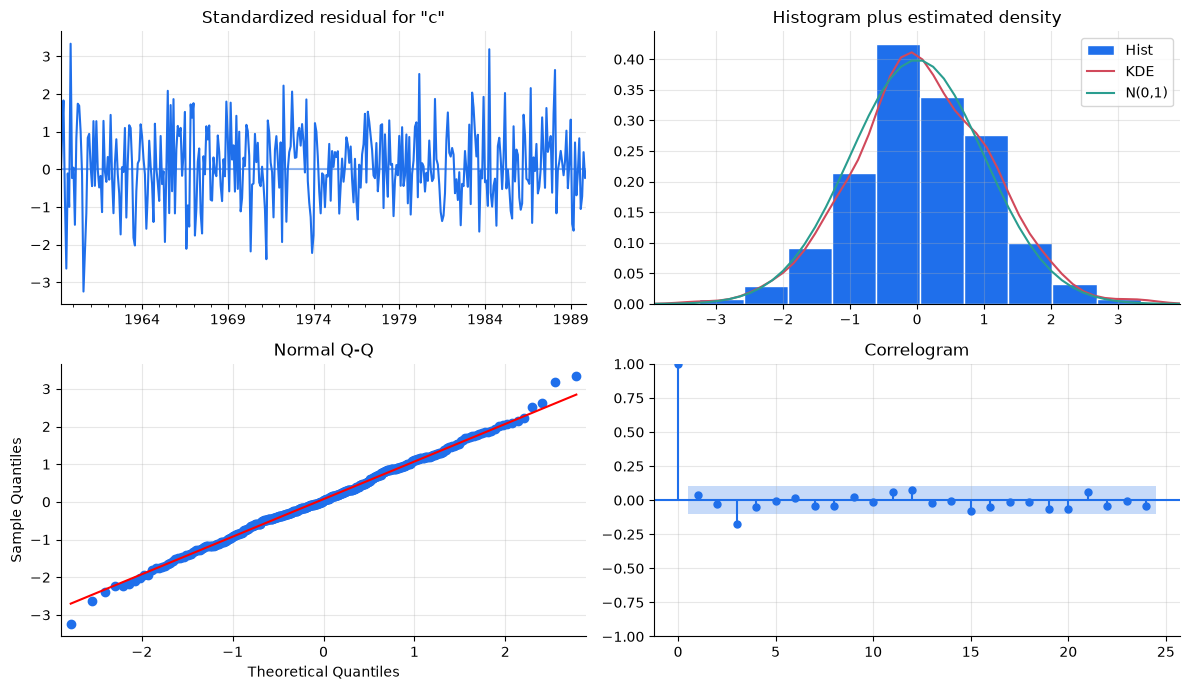

In [6]:
from statsmodels.stats.stattools import durbin_watson

airline_fit = co2_fits["airline (0,1,1)(0,1,1)"]
airline_fit.plot_diagnostics(figsize=(12, 7), lags=24)
plt.tight_layout()

jb_stat, jb_p, skew, kurtosis = airline_fit.test_normality("jarquebera")[0]
het_stat, het_p = airline_fit.test_heteroskedasticity("breakvar")[0]
pd.Series({
    "Jarque–Bera p-value": jb_p, "skewness": skew, "kurtosis": kurtosis,
    "heteroskedasticity p-value": het_p,
    "Durbin–Watson": durbin_watson(airline_fit.resid.iloc[13:]),
}).round(3).to_frame("airline model")

Apart from the small Ljung–Box warning above, the airline model passes: residuals look **normal** (Jarque–Bera p ≈ 0.6, skewness near 0, kurtosis near 3), there's **no significant change in variance**, and **Durbin–Watson ≈ 1.9**, close to 2. These checks are about the *model's assumptions*, which matter most for its **prediction intervals**. The backtest below remains the judge of its **forecasts**.

### Letting the computer search: `auto_arima`

Choosing orders by hand, from ACF plots and a small grid, is instructive but slow. The **`pmdarima`** package ports R's `auto.arima` (Hyndman & Khandakar, 2008), a **stepwise search**. It starts from a few simple models, repeatedly tries neighbouring orders (one more or one fewer AR or MA term, seasonal or not), and keeps moving while AIC improves. We fix $d = D = 1$ from chapter 03 and let it search the rest. It fits a few dozen models, so this cell takes a minute or so.

In [7]:
import pmdarima as pm

auto_fit = pm.auto_arima(co2_train, seasonal=True, m=12, d=1, D=1, stepwise=True,
                         suppress_warnings=True, error_action="ignore")
print(f"auto_arima chose {auto_fit.order}{auto_fit.seasonal_order}, AIC {auto_fit.aic():.1f} "
      f"(airline: {co2_fits['airline (0,1,1)(0,1,1)'].aic:.1f})")

auto_arima chose (0, 1, 3)(0, 1, 1, 12), AIC 193.4 (airline: 203.6)


The search goes further than our small grid could. It adds extra MA terms and lowers AIC below both of our candidates. Whether that buys better *forecasts* is a separate question, the one Exercise 4 raises for the (1,1,1) model, so we include `auto_arima`'s pick in the backtest.

> **Use the automation, keep the judgement.** An automatic search optimises one in-sample number over a limited menu of models. It won't tell you that a series needs a log transform, that a structural break happened, or that the backtest disagrees. Check its choice with the same diagnostics and backtests as any hand-picked model.

In [8]:
co2_origins = pd.date_range("1990-01-01", "2000-12-01", freq="QS")      # quarterly, to keep runtime modest
co2_coverage = []

def airline_forecast(history, horizon):
    fit = SARIMAX(history, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False)
    prediction = fit.get_forecast(horizon)
    band = prediction.conf_int(alpha=0.2).to_numpy()
    target = co2.reindex(pd.date_range(history.index[-1] + pd.offsets.MonthBegin(1), periods=horizon, freq="MS")).to_numpy()
    co2_coverage.append(np.where(np.isnan(target), np.nan, (target >= band[:, 0]) & (target <= band[:, 1])))
    return prediction.predicted_mean.to_numpy()

def holt_winters(seasonal):
    return lambda history, horizon: ExponentialSmoothing(
        history.to_numpy(), trend="add", seasonal=seasonal, seasonal_periods=12,
        initialization_method="estimated").fit().forecast(horizon)

def seasonal_naive_drift(history, horizon, period=12):
    growth = history.iloc[-period:].mean() - history.iloc[-2 * period:-period].mean()
    last_year = np.tile(history.iloc[-period:].to_numpy(), int(np.ceil(horizon / period)))[:horizon]
    return last_year + growth * np.ceil(np.arange(1, horizon + 1) / period)

co2_models = {
    "baseline: seasonal naive + drift": seasonal_naive_drift,
    "Holt-Winters (additive)": holt_winters("add"),
    "Holt-Winters (multiplicative)": holt_winters("mul"),
    "SARIMA airline": airline_forecast,
    f"SARIMA auto_arima {auto_fit.order}{auto_fit.seasonal_order}": lambda history, horizon: SARIMAX(
        history, order=auto_fit.order, seasonal_order=auto_fit.seasonal_order).fit(disp=False).forecast(horizon).to_numpy(),
}
co2_table = pd.DataFrame({name: tsutils.evaluate(tsutils.backtest(co2, f, co2_origins, 12))["MAE"]
                          for name, f in co2_models.items()})
co2_table.loc[[1, 3, 6, 12]].T

h,1,3,6,12
baseline: seasonal naive + drift,0.494,0.564,0.683,0.842
Holt-Winters (additive),0.225,0.357,0.489,0.644
Holt-Winters (multiplicative),0.229,0.336,0.471,0.671
SARIMA airline,0.218,0.310,0.437,0.643
"SARIMA auto_arima (0, 1, 3)(0, 1, 1, 12)",0.221,0.336,0.461,0.656


The airline model edges out both Holt-Winters versions at most horizons. They're close competitors: both families were built for this kind of series, and the differences are a few hundredths of a ppm.

`auto_arima`'s pick, despite its clearly lower AIC, forecasts **slightly worse than the airline model at every horizon**. The extra MA terms fit the 1958–1989 history a little better, but they don't carry over to the future. This is the "keep the judgement" warning in practice: the two-parameter classic, chosen by BIC and the ACF, wins where it counts.

How about the intervals?

In [9]:
pd.Series(np.nanmean(co2_coverage, axis=0), index=pd.RangeIndex(1, 13, name="months ahead"),
          name="coverage of 80% interval").to_frame().T.style.format("{:.0%}")

months ahead,1,2,3,4,5,6,7,8,9,10,11,12
coverage of 80% interval,86%,80%,86%,75%,73%,80%,75%,75%,75%,75%,80%,82%


Like ETS in chapter 05, SARIMA's model-based intervals run **a little narrow** at medium horizons: about three in four actuals land inside a nominal 80% band. That's the same El Niño story. Occasional bursts of faster growth are bigger than the model's Gaussian errors allow for.

---
## 3. SARIMAX: bringing in the weather

**SARIMAX** adds external ("exogenous") regressors $x_t$. The cleanest way to read it is as a **regression with ARMA errors**:

$$a_t = \beta_0 + \beta^\top x_t + \eta_t, \qquad \eta_t \sim \text{ARMA}(p, q).$$

Here $a_t$ is the log PM2.5 anomaly from chapter 06, the deviation from the seasonal profile. The regression part says how the weather moves PM2.5. The ARMA errors capture the memory that remains after accounting for the weather.

`tsutils.load_daily_weather()` summarises the hourly weather into daily features. Chapter 01's wind-direction exercise already hinted at which ones matter.

In [10]:
weather = tsutils.load_daily_weather()

def anomalies(series, profile):
    return np.log(series) - profile.reindex(series.index.dayofyear).to_numpy()

train = y[:"2013-12-31"]
profile = tsutils.log_climatology_profile(train)
train_anomaly = anomalies(train, profile)

same_day = ["dew_point", "humidity", "pressure", "temp", "precip", "nw_share", "calm_share", "wind"]
weather.loc[train.index, same_day].corrwith(train_anomaly).sort_values().round(2).to_frame("correlation with same-day PM2.5 anomaly")

,correlation with same-day PM2.5 anomaly
nw_share,-0.49
wind,-0.40
pressure,-0.11
temp,-0.00
precip,0.01
dew_point,0.23
calm_share,0.44
humidity,0.53


The pattern makes physical sense:

- **Humid, calm days are polluted.** Moist, stagnant air traps particles and helps secondary particles form.
- **North-westerly wind and high wind speeds clean the air.** Dry air from the north-west sweeps pollution out of the city.

### Lead or lag? Cross-correlation

A same-day correlation can't tell us whether the weather *drives* PM2.5 or merely moves *with* it. The **cross-correlation function (CCF)** helps by shifting one series against the other: the correlation between PM2.5 today and the weather $k$ days **earlier**, for a range of $k$. If a variable's influence arrives with a delay, its correlation peaks at a positive lag.

In [11]:
lead_lag = pd.DataFrame({
    column: {k: np.corrcoef(weather.loc[train.index, column].shift(k).iloc[10:-10],
                            train_anomaly.iloc[10:-10])[0, 1]
             for k in range(-2, 4)}
    for column in ["nw_share", "nw_evening", "humidity", "pressure_change"]
})
lead_lag.index.name = "weather this many days earlier"
lead_lag.round(2)

,nw_share,nw_evening,humidity,pressure_change
weather this many days earlier,,,,
-2,-0.04,0.02,0.17,0.21
-1,-0.13,-0.04,0.34,0.06
0,-0.50,-0.28,0.53,-0.38
1,-0.42,-0.54,0.21,-0.12
2,-0.11,-0.20,0.02,0.04
3,-0.01,-0.04,-0.03,0.03


Most variables correlate most strongly on the **same day** (lag 0), with a weaker echo at lag 1, partly because both PM2.5 and weather are autocorrelated. **Evening north-westerly wind is the exception**: its strongest correlation is with PM2.5 **the following day** (lag 1). An evening wind shift is the leading edge of the air mass that clears the next day's smog. We'll exploit exactly this lead in section 4.

Two cautions for reading a CCF. First, autocorrelation in *both* series inflates correlations at neighbouring lags, so a peak's location is more trustworthy than the exact values. The rigorous fix is to *prewhiten* both series with an ARMA filter first. Second, a lead is evidence of predictive value, not proof of causation (chapter 03's spurious correlations).

Now fit the model on 2010–2013, with the weather standardised so the coefficients are comparable:

In [12]:
X_train = weather.loc[train.index, same_day]
X_std = (X_train - X_train.mean()) / X_train.std()

no_weather = SARIMAX(train_anomaly.to_numpy(), order=(2, 0, 0), trend="c").fit(disp=False)
with_weather = SARIMAX(train_anomaly, exog=X_std, order=(2, 0, 0), trend="c").fit(disp=False)

print(f"AIC without weather: {no_weather.aic:.0f}   with weather: {with_weather.aic:.0f}")
with_weather.summary().tables[1]

AIC without weather: 3049   with weather: 2086


,coef,std err,z,P>|z|,[0.025,0.975]
intercept,-0.0143,0.014,-1.000,0.317,-0.042,0.014
dew_point,0.2144,0.158,1.353,0.176,-0.096,0.525
humidity,0.3499,0.068,5.179,0.000,0.217,0.482
pressure,-0.3789,0.038,-10.085,0.000,-0.453,-0.305
temp,-0.5929,0.124,-4.766,0.000,-0.837,-0.349
precip,-0.0389,0.007,-5.220,0.000,-0.054,-0.024
nw_share,-0.1334,0.017,-7.754,0.000,-0.167,-0.100
calm_share,0.0626,0.016,3.994,0.000,0.032,0.093
wind,-0.0531,0.014,-3.666,0.000,-0.082,-0.025
ar.L1,0.5861,0.027,21.946,0.000,0.534,0.638


AIC falls by about **a third**. Same-day weather explains a large share of what the AR(2) alone called "noise". Each coefficient is the change in log PM2.5 for a one-standard-deviation change in that weather variable, holding the others fixed:

- **Humidity** and **calm** conditions push PM2.5 up. **North-westerly wind**, **wind speed**, **rain** (which washes particles out) and **higher pressure** push it down.
- **Dew point** is no longer significant. It moves together with humidity and temperature, so once those are in the model it adds little. Coefficients of correlated inputs should be read with care: the model can shift weight between them without changing its forecasts much.
- The **second AR coefficient has collapsed to about zero**. In chapter 06, AR(2) needed that lag to capture how quickly episodes clear. We can now see what it was standing in for: the **weather**. Sharp clean-ups are fronts arriving, and once the model sees the wind, one lag of memory is enough. This is a common pattern, where apparent dynamics in a series turn out to be the footprint of a missing driver.

---
## 4. The question that decides honesty: what is the future weather?

This fit used each day's **observed** weather. To forecast next Tuesday, we'd need next Tuesday's weather, which hasn't happened yet. Our dataset has no weather *forecasts*, only what actually occurred. There are three ways to handle this:

| Approach | Future weather fed to the model | Honest? |
|---|---|---|
| **A. Oracle** | the weather that actually happened | ❌ uses the future, but it shows the **upper bound** a perfect weather forecast would give |
| **B. Naive weather forecast** | today's weather, repeated | ✅ uses only the past |
| **C. Only what's known today** | a model built so that tomorrow's PM2.5 depends on **today's** weather | ✅ uses only the past |

Approach A is only acceptable because it's **labelled and kept out of the leaderboard**. Its scores go to a separate file, `tsutils.ORACLE_RESULTS_PATH`.

### A practical refit schedule

Refitting a SARIMAX with eight regressors at every one of 359 origins is slow. A common production pattern is to **refit the parameters once a month**, and in between **update the model with each new day's data** using the fixed parameters. statsmodels' `results.apply(new_data)` does exactly that update. The parameters only ever come from data before the refit date, so nothing leaks.

In [13]:
def weather_forecaster(features, lag=0, future="mean", future_source=None, order=(2, 0, 0)):
    """Seasonal log profile + SARIMAX(order) on anomalies with weather regressors.

    lag:     0 -> each day's PM2.5 is explained by that day's weather
             1 -> ... by the previous day's weather
    future:  how to fill regressor values not yet observed at the origin:
             "oracle"  - the actual weather (from `future_source`, default the real data)
             "persist" - repeat the origin day's weather
             "mean"    - the historical average (i.e. "no information")
    Parameters are refitted at the first origin of each month and reused until the next.
    """
    lagged = weather[features].shift(lag)
    lagged_future = (weather if future_source is None else future_source)[features].shift(lag)
    cache = {}

    def forecast(history, horizon):
        origin = history.index[-1]
        month = (origin.year, origin.month)
        if month not in cache:
            profile_ = tsutils.log_climatology_profile(history)
            X_hist = lagged.loc[history.index].iloc[lag:]
            mean, std = X_hist.mean(), X_hist.std()
            fit = SARIMAX(anomalies(history, profile_).iloc[lag:].to_numpy(),
                          exog=((X_hist - mean) / std).to_numpy(), order=order, trend="c").fit(disp=False)
            cache[month] = (profile_, mean, std, fit)
        profile_, mean, std, fit = cache[month]

        X_hist = ((lagged.loc[history.index].iloc[lag:] - mean) / std).to_numpy()
        updated = fit.apply(anomalies(history, profile_).iloc[lag:].to_numpy(), exog=X_hist)

        targets = pd.date_range(origin + pd.Timedelta(days=1), periods=horizon, freq="D")
        X_future = lagged_future.loc[targets].copy()
        unknown = (targets - pd.Timedelta(days=lag)) > origin     # regressor values not yet observed
        if future == "persist":
            X_future.loc[unknown] = weather.loc[origin, features].to_numpy()
        elif future == "mean":
            X_future.loc[unknown] = mean.to_numpy()
        X_future = ((X_future - mean) / std).to_numpy()

        seasonal = profile_.reindex(targets.dayofyear).to_numpy()
        return np.exp(updated.forecast(horizon, exog=X_future) + seasonal)

    return forecast

First, a sanity check on the refit schedule. With **no** weather, monthly refits should score almost exactly like chapter 06's AR(2), which refitted every day. We handle "no regressors" with a tiny wrapper:

In [14]:
def ar2_monthly_refit():
    cache = {}
    def forecast(history, horizon):
        origin = history.index[-1]
        month = (origin.year, origin.month)
        if month not in cache:
            profile_ = tsutils.log_climatology_profile(history)
            cache[month] = (profile_, SARIMAX(anomalies(history, profile_).to_numpy(),
                                              order=(2, 0, 0), trend="c").fit(disp=False))
        profile_, fit = cache[month]
        updated = fit.apply(anomalies(history, profile_).to_numpy())
        targets = pd.date_range(origin + pd.Timedelta(days=1), periods=horizon, freq="D")
        return np.exp(updated.forecast(horizon) + profile_.reindex(targets.dayofyear).to_numpy())
    return forecast

monthly = tsutils.evaluate(tsutils.backtest(y, ar2_monthly_refit(), origins, H, actuals=actual))
board = tsutils.load_scores().pivot(index="h", columns="model", values="MAE")
pd.DataFrame({"AR(2), refit daily (ch. 06)": board["AR(2) on anomalies"], "AR(2), refit monthly": monthly["MAE"]})

,"AR(2), refit daily (ch. 06)","AR(2), refit monthly"
h,,
1,46.803,46.936
2,55.419,55.581
3,56.264,56.432
4,56.533,56.731
5,56.587,56.747
6,56.491,56.677
7,56.407,56.547


Practically identical, so the schedule costs nothing in accuracy. Now the three approaches.

### A. The oracle: perfect weather forecasts

In [15]:
oracle = tsutils.evaluate(tsutils.backtest(y, weather_forecaster(same_day, lag=0, future="oracle"),
                                           origins, H, actuals=actual))
tsutils.save_scores("ORACLE: SARIMAX with actual future weather", oracle, path=tsutils.ORACLE_RESULTS_PATH)
oracle[["MAE", "RMSE"]].T

h,1,2,3,4,5,6,7
MAE,34.172,42.827,46.197,47.723,48.823,49.481,49.679
RMSE,50.895,64.262,69.680,71.623,72.796,73.812,74.108


### B. The same model, with a naive weather forecast

In [16]:
persisted = tsutils.evaluate(tsutils.backtest(y, weather_forecaster(same_day, lag=0, future="persist"),
                                              origins, H, actuals=actual))
tsutils.save_scores("SARIMAX, weather persisted", persisted)
persisted[["MAE", "RMSE"]].T

h,1,2,3,4,5,6,7
MAE,50.177,66.730,70.935,71.757,68.258,66.357,67.962
RMSE,69.778,91.241,95.748,97.557,94.821,93.577,95.444


### C. Use only what's known today

Approach C changes the model instead of the inputs. It regresses each day's anomaly on the **previous** day's weather. At the forecast origin (the end of day $T$), today's weather is fully observed, so the forecast for day $T + 1$ uses real information. For later days, the regressors are unknown and set to their average, so those forecasts rely on the AR memory alone.

Which of today's weather features say something about *tomorrow*? The best candidates describe **changes in progress**: the evening wind (a north-westerly arriving after dark signals tomorrow's clean-up), and today's change in pressure and humidity (a cold front passing).

In [17]:
known_today = ["nw_share", "calm_share", "humidity", "wind",
               "nw_evening", "humidity_evening", "pressure_change", "humidity_change"]

ar2_residual = pd.Series(no_weather.resid, index=train.index)
(weather[known_today].shift(1).loc[train.index].corrwith(ar2_residual)
 .sort_values().round(2).to_frame("correlation with the part of PM2.5 AR(2) can't predict"))

,correlation with the part of PM2.5 AR(2) can't predict
nw_evening,-0.44
nw_share,-0.18
humidity,-0.06
wind,-0.05
humidity_change,-0.04
humidity_evening,0.06
calm_share,0.08
pressure_change,0.13


**Evening north-westerly wind** stands out. It predicts much of what the AR(2) model gets wrong about tomorrow, because it's the leading edge of the weather change that clears the smog.

In [18]:
honest = tsutils.evaluate(tsutils.backtest(y, weather_forecaster(known_today, lag=1, future="mean"),
                                           origins, H, actuals=actual))
tsutils.save_scores("SARIMAX, today's weather", honest)
honest[["MAE", "RMSE"]].T

h,1,2,3,4,5,6,7
MAE,40.937,55.956,56.834,56.809,56.687,56.634,56.545
RMSE,61.627,82.695,84.237,84.488,84.419,84.418,84.331


---
## 5. What the three approaches tell us

,climatology (median),AR(2) on anomalies (ch. 06),B: weather persisted,C: today's weather,A: ORACLE (perfect weather)
h,,,,,
1,56.079,46.803,50.177,40.937,34.172
2,56.561,55.419,66.730,55.956,42.827
3,56.771,56.264,70.935,56.834,46.197
4,57.133,56.533,71.757,56.809,47.723
5,57.099,56.587,68.258,56.687,48.823
6,57.132,56.491,66.357,56.634,49.481
7,57.068,56.407,67.962,56.545,49.679


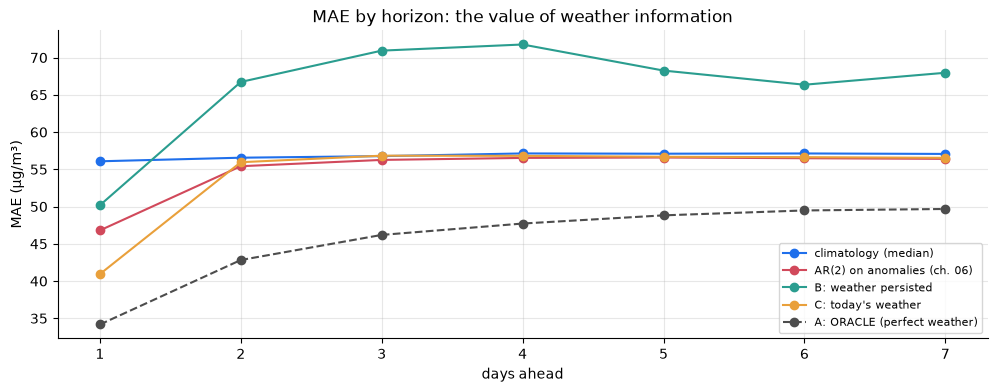

In [19]:
comparison = pd.DataFrame({
    "climatology (median)": board["climatology (median)"],
    "AR(2) on anomalies (ch. 06)": board["AR(2) on anomalies"],
    "B: weather persisted": persisted["MAE"],
    "C: today's weather": honest["MAE"],
    "A: ORACLE (perfect weather)": oracle["MAE"],
})

fig, ax = plt.subplots()
for name, column in comparison.items():
    style = dict(ls="--", color="0.3") if name.startswith("A:") else {}
    ax.plot(column.index, column, marker="o", label=name, **style)
ax.set(title="MAE by horizon: the value of weather information", xlabel="days ahead", ylabel="MAE (µg/m³)")
ax.legend(fontsize=8)
comparison

Three lessons, one per approach:

**A. Perfect weather would be worth a lot.** The oracle cuts the one-day error by roughly a quarter against the AR(2), and stays well ahead at every horizon. With a perfect weather forecast, PM2.5 would be far more predictable a week out than anything we've managed so far. This number isn't achievable. It's a **ceiling**, and it tells you how much a *real* weather forecast could be worth.

**B. Bad inputs are worse than no inputs.** Feeding the same model "tomorrow's weather = today's" makes it **worse than ignoring the weather altogether**, at every horizon. The model learned that weather effects are strong, so it trusts its weather inputs, and a naive weather forecast is often wrong in exactly the situations that matter, like the day a front arrives. A model trained on perfect inputs and run on rough ones is a very common failure in practice, and it's easy to miss if you only ever evaluate with the oracle.

**C. Honest information helps where it exists.** Building the model around what's actually known gives the **best honest one-day forecast so far**, a clear gain over AR(2). The evening wind carries real, observable news about tomorrow. From day 2 on it's level with AR(2), a fraction behind, because today's weather says nothing reliable about the day after tomorrow. Closing that gap to the oracle would take **real weather forecasts** as inputs, which is exactly what operational air-quality services use.

> **Rule for the rest of the course:** any input a model uses at forecast time must be something you would actually have at that time. When a study reports skill from inputs like observed future weather, check whether it's quietly an oracle.

---
## Exercises

### Exercise 1: The airline model's autocorrelation fingerprint
Multiplying out $(1 + \theta B)(1 + \Theta B^{12})$ gives MA coefficients at lags 1, 12 and 13. Using the fitted airline model's $\theta$ and $\Theta$ (from `co2_fits`), build the 13-coefficient MA polynomial and compute its **theoretical** ACF with `ArmaProcess`. Plot it next to the sample ACF of `double_diff`. Where are the non-zero lags, and why is there one at lag 11?

<details><summary>Solution</summary>

```python
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import acf

airline = co2_fits["airline (0,1,1)(0,1,1)"]
th, Th = airline.params["ma.L1"], airline.params["ma.S.L12"]
ma = np.zeros(13)
ma[0], ma[11], ma[12] = th, Th, th * Th            # lags 1, 12 and 13
theory = ArmaProcess.from_coeffs([], ma).acf(25)[1:]
sample = acf(double_diff, nlags=24)[1:]

lags_ = np.arange(1, 25)
plt.vlines(lags_, 0, sample, lw=3, alpha=0.5, label="sample")
plt.plot(lags_, theory, "o", color="#d1495b", label="airline theory")
plt.axhline(0, color="k", lw=0.8)
plt.legend()
plt.title("ACF of the doubly-differenced CO₂")
print(pd.Series(theory, index=lags_).round(2).loc[lambda s: s.abs() > 0.01])
```
The theoretical ACF is non-zero only at lags **1, 11, 12 and 13**. Lag 11 appears because the shock at lag 1 and the shock at lag 12 are 11 steps apart. Two MA parameters generate this whole pattern, and the sample ACF follows it closely, which is why the airline model fits so many monthly series with trend and seasonality.
</details>

### Exercise 2: How much is the evening wind worth?
Refit approach C **without** `nw_evening` and compare the one-day-ahead MAE with the full honest model. This is an *ablation*: removing one input to measure its contribution.

<details><summary>Solution</summary>

```python
without_evening = [f for f in known_today if f != "nw_evening"]
ablated = tsutils.evaluate(tsutils.backtest(y, weather_forecaster(without_evening, lag=1, future="mean"),
                                            origins, H, actuals=actual))
pd.DataFrame({"with nw_evening": honest["MAE"], "without": ablated["MAE"]}).loc[[1, 2]]
```
Removing the evening wind gives back a good part of the one-day improvement. Other features, like the daily north-west share and the pressure change, carry some of the same information, so the loss is smaller than the feature's correlation alone would suggest. Ablations measure what a feature adds *given the others*, and that's usually less than what it shows on its own.
</details>

### Exercise 3: How good does a weather forecast have to be?
Real weather forecasts are imperfect, and they get worse with lead time. Simulate that. Add random noise to the actual weather, with a standard deviation of 0.5× and then 1.0× each variable's own standard deviation, and pass it as `future_source` to the oracle model. Where do the noisy versions fall between approach B, the oracle, and the AR(2) without weather?

<details><summary>Solution</summary>

```python
noise_rng = np.random.default_rng(0)
noisy_results = {}
for scale in [0.5, 1.0]:
    noisy = weather.copy()
    scale_by = weather.loc[:tsutils.DEV_END, same_day].std().to_numpy()      # development-period spread
    noisy[same_day] += noise_rng.normal(size=(len(weather), len(same_day))) * scale_by * scale
    noisy_results[f"noise {scale}×sd"] = tsutils.evaluate(tsutils.backtest(
        y, weather_forecaster(same_day, lag=0, future="oracle", future_source=noisy),
        origins, H, actuals=actual))["MAE"]

pd.DataFrame({"ORACLE": oracle["MAE"], **noisy_results,
              "AR(2), no weather": board["AR(2) on anomalies"], "B: persisted": persisted["MAE"]})
```
The advantage disappears fast. With noise of **half** each variable's spread, the weather model is already **worse than AR(2) with no weather at all**, at every horizon. With noise as large as the weather's own variability, errors nearly double. The model's coefficients were learned from accurate weather, so it passes every input error straight into the forecast, and with eight inputs the errors add up.

Two caveats keep this from being as bleak as it looks. Real day-ahead weather forecasts are much better than half-spread noise, and their errors are correlated across variables and grow with lead time, unlike this independent noise. Still, the lesson holds. **An exogenous-input model is only as good as its input forecasts, and it can be worse than no inputs.** The standard remedy is to train the model on *forecast* weather, the inputs it will actually receive, so it learns how much to trust them.
</details>

### Exercise 4: Do cleaner residuals mean better forecasts?
AIC and the Ljung–Box test preferred (1,1,1)(0,1,1)₁₂ to the airline model. Backtest it on the same quarterly CO₂ origins and compare MAE by horizon.

<details><summary>Solution</summary>

```python
def sarima_111(history, horizon):
    return SARIMAX(history, order=(1, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False).forecast(horizon).to_numpy()

alt = tsutils.evaluate(tsutils.backtest(co2, sarima_111, co2_origins, 12))["MAE"]
pd.DataFrame({"airline": co2_table["SARIMA airline"], "(1,1,1)(0,1,1)": alt}).loc[[1, 3, 6, 12]]
```
The two forecast almost identically, and if anything the airline model is slightly *better* at every horizon. The extra AR term mops up a small amount of residual autocorrelation, but that structure is too weak to help the forecasts, and the extra parameter adds a little estimation noise. "The residuals pass Ljung–Box" is a useful diagnostic. It isn't the same as "the forecasts are better", and when the gain is this small, the simpler model is easier to explain and maintain.
</details>

---
## Key takeaways

- **ARIMA** puts differencing inside the model. ARIMA(0,1,1) *is* SES, which is why SES can't revert to a mean.
- **SARIMA** adds seasonal differencing and seasonal AR/MA terms that multiply with the regular ones. The **airline model** (0,1,1)(0,1,1)₁₂ is the classic, identified from spikes at lags 1 and 12 of the doubly-differenced ACF, and it edges out Holt-Winters on CO₂.
- Residual checks test the model's **assumptions**, which matter for intervals. `auto_arima` automates the order search. The backtest still judges the forecasts.
- A **cross-correlation** revealed that evening wind *leads* PM2.5 by a day.
- **SARIMAX** = regression on external inputs + ARMA errors. Same-day weather explains a large share of PM2.5's day-to-day swings.
- **Future inputs decide honesty.** With perfect weather (the *oracle*, kept off the leaderboard) errors fall sharply. Naively guessed weather, or even moderately noisy weather (Exercise 3), makes the model **worse** than no weather. Weather that's genuinely known today gives the **best honest one-day forecast** so far.
- **Refit monthly, update daily** is a practical schedule that costs nothing in accuracy here.

**Next:** *08 · Prophet*. A very different philosophy: a curve-fitting model with trend changepoints, multiple seasonalities and holidays, built for business forecasting at scale. We'll see how it fares on the same tasks.